## Space varrying material properties

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import time
import scienceplots
plt.style.use(['science','grid'])

# fix random seed
np.random.seed(42)

In [8]:
def correlation_function(distance,i=2):
    """Exponential correlation function."""
    return np.exp(-distance**i)

def compute_correlation_matrix(grid,kernel, bx,by):
    """Compute the correlation matrix for a 2D grid."""
    N = grid.shape[0]
    C = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = np.sqrt(((grid[i, 0] - grid[j, 0])/bx)**2 + ((grid[i, 1] - grid[j, 1])/by)**2)
            C[i, j] = kernel(d)
    return C


def KL_expansion(grid, kernel, C_param,truncation_order):
    """Compute the KL expansion."""
    N = grid.shape[0]
    mu = C_param[0]
    sigma = C_param[1]
    bx = C_param[2]
    by = C_param[3]
    C = compute_correlation_matrix(grid, kernel, bx, by)
    eig_values, eig_vectors = np.linalg.eigh(C)
    # Sort eigenvalues and eigenvectors
    idx = eig_values.argsort()[::-1]
    eig_values = eig_values[idx]
    eig_vectors = eig_vectors[:, idx]

    return eig_values[:truncation_order], eig_vectors[:, :truncation_order]

# Material parameters: [mu, sigma, bx, by]
# C11param = [1.55, 0.129, 20.18, 16.6]   
# C33param = [0.316, 0.027, 20.86, 15.08] --> from original paper
C11param = [1.55, 0.129, 50, 50] 
C33param = [0.316, 0.027, 50, 50] # --> increase spatial correlation to limit number KL terms

# Parameters
N = 27
Lmax = 100

# Create 2D grid
x = np.linspace(0, Lmax, N)
y = np.linspace(0, Lmax, N)
X, Y = np.meshgrid(x, y)
grid = np.column_stack((X.ravel(), Y.ravel()))

truncation_order = N**2 # Keep all modes (= number of grid points)

# Spectral decomposition
load_KL = False
if load_KL:
    eig_values_C11 = np.load("eig_values_C11.npy")
    eig_vectors_C11 = np.load("eig_vectors_C11.npy")
    eig_values_C33 = np.load("eig_values_C33.npy")
    eig_vectors_C33 = np.load("eig_vectors_C33.npy")
else:
    eig_values_C11, eig_vectors_C11 = KL_expansion(grid, correlation_function, C11param, truncation_order)
    eig_values_C33, eig_vectors_C33 = KL_expansion(grid, correlation_function, C33param, truncation_order)

    #thresholding at 0 eigenvalues
    eig_values_C11[eig_values_C11<0]=0
    eig_values_C33[eig_values_C33<0]=0

    np.save("eig_values_C11.npy", eig_values_C11)
    np.save("eig_vectors_C11.npy", eig_vectors_C11)
    np.save("eig_values_C33.npy", eig_values_C33)
    np.save("eig_vectors_C33.npy", eig_vectors_C33)

def C_from_xi(xi, eig_values, eig_vectors, C_param):
    """Compute the Lognormal field from the KL expansion."""
    N = int(np.sqrt(eig_vectors.shape[0]))
    Nsim = xi.shape[0]
    XC = eig_vectors @ (np.sqrt(eig_values) * xi).T
    C = np.exp(C_param[0] + C_param[1] * XC)
    C = C.reshape((N, N, Nsim))
    return C

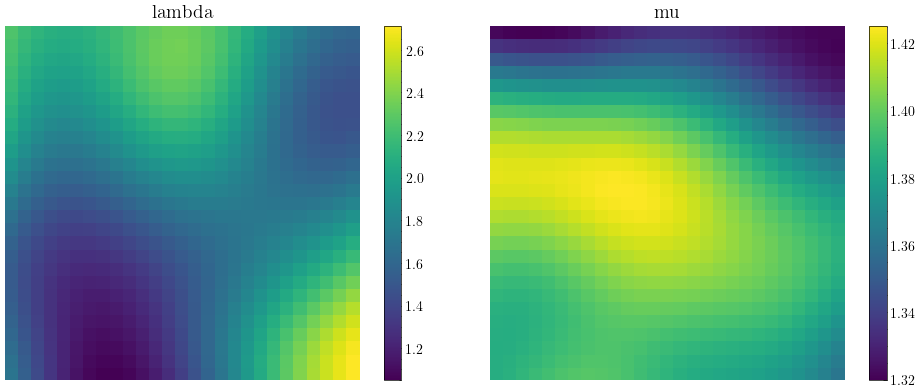

In [7]:
#plotting utility function
def pcolor_plot(AX, X, Y, C, title,colormap="viridis",set_axis = 'off',**kwargs):
    ## plot the pcolor plot of the given data C on the given axis AX with the given title and optional colorbar limits cmin and cmax
    if len(kwargs) == 0:
        im = AX.pcolor(X, Y, C, cmap=colormap,shading='auto')
    else:
        cmin = kwargs["cmin"]
        cmax = kwargs["cmax"]
        im = AX.pcolor(X, Y, C, cmap=colormap, vmin=cmin, vmax=cmax,shading='auto')
    AX.set_aspect("equal", "box")
    AX.axis(set_axis)
    AX.set_title(title, fontsize=14)
    return im


n_xi_samples = 1

load_samples = True
if load_samples:
    U_C11 = np.load("U_C11.npy")
    U_C33 = np.load("U_C33.npy")
else:
    U_C11 = np.random.randn(n_xi_samples,N**2)
    U_C33 = np.random.randn(n_xi_samples,N**2)

    # Save random variables
    np.save("U_C11.npy", U_C11)
    np.save("U_C33.npy", U_C33)


# Compute random coefficients
C11 = C_from_xi(U_C11, eig_values_C11, eig_vectors_C11, C11param)
C33 = C_from_xi(U_C33, eig_values_C33, eig_vectors_C33, C33param)

# compute lambda and mu
lmbd = C11 - 2*C33
mu = C33

# Plot first realization of lambda and mu fields
fig,ax = plt.subplots(1,2,figsize=(10,4))

imLambda = pcolor_plot(ax[0], X, Y, lmbd[:,:,0], "lambda")
fig.colorbar(imLambda, ax=ax[0])
imMu = pcolor_plot(ax[1], X, Y, mu[:,:,0], "mu")
fig.colorbar(imMu, ax=ax[1])
plt.tight_layout()

In [ ]:
# The code has been tested with both JAX and PyTorch backends. It should work with TensorFlow/Paddle as well but has not been tested.
# JAX is recommended for higher computational performance (x10-x20 faster than PyTorch in our implementation).
import deepxde as dde
from jax.scipy.interpolate import RegularGridInterpolator
import jax.numpy as jnp

# Define functions
sin = dde.backend.sin
cos = dde.backend.cos
stack = dde.backend.stack

net_type = ["spinn","pinn"][0]
Lmax = 100.0
pstress = 0.1

X_interp = np.linspace(0, Lmax, N)
Y_interp = np.linspace(0, Lmax, N)
# create C interpolation function
def create_interpolation_fn(data_array):
    return RegularGridInterpolator((X_interp, Y_interp), data_array)

lmbd_fun = [create_interpolation_fn(lmbd[:,:,i]) for i in range(n_xi_samples)]
mu_fun = [create_interpolation_fn(mu[:,:,i]) for i in range(n_xi_samples)]

Exx_mean_fem = 0.02571187493951528
Eyy_mean_fem = -0.010741097568904246

def transform_coords(x):
    """
    For SPINN, if the input x is provided as a list of 1D arrays (e.g., [X_coords, Y_coords]),
    this function creates a 2D meshgrid and stacks the results into a 2D coordinate array.
    """
    x_mesh = [x_.ravel() for x_ in jnp.meshgrid(jnp.atleast_1d(x[0].squeeze()), jnp.atleast_1d(x[1].squeeze()), indexing="ij")]
    return dde.backend.stack(x_mesh, axis=-1)



Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [24]:
# Load fem reference solution
fem_file = "fem_100x100nodes.dat"

data = np.loadtxt(fem_file)
X_val      = data[:, :2]
u_val      = data[:, 2:4]
strain_val = data[:, 4:7]
stress_val = data[:, 7:10]

n_mesh_points = int(np.sqrt(X_val.shape[0]))
x_grid = np.linspace(0, Lmax, n_mesh_points)
y_grid = np.linspace(0, Lmax, n_mesh_points)

def create_interpolation_fn(data_array):
    num_components = data_array.shape[1]
    interpolators = []
    for i in range(num_components):
        interp = RegularGridInterpolator(
            (x_grid, y_grid),
            data_array[:, i].reshape(n_mesh_points, n_mesh_points).T,
        )
        interpolators.append(interp)
    def interpolation_fn(x):
        x_in = transform_coords([x[0], x[1]])
        return np.array([interp((x_in[:, 0], x_in[:, 1])) for interp in interpolators]).T
    return interpolation_fn

solution_fn = create_interpolation_fn(u_val)
strain_fn   = create_interpolation_fn(strain_val)
stress_fn   = create_interpolation_fn(stress_val)

In [10]:
geom = dde.geometry.Rectangle([0, 0], [Lmax, Lmax])
BC_type = ["hard", "soft"][0]
coord_normalization = True
# x_max = 1.0 if coord_normalization else Lmax
num_bc_points = 25

bc_linspace = np.linspace(0, Lmax, num_bc_points).reshape(-1,1)
if net_type != "spinn":
    bc_0 = np.zeros_like(bc_linspace)
    bc_Lmax = Lmax*np.ones_like(bc_linspace)
else:
    bc_0 = np.array([0]).reshape(-1,1)
    bc_Lmax = np.array([Lmax]).reshape(-1,1)

bc_point_left = [bc_0, bc_linspace]
bc_point_right = [bc_Lmax, bc_linspace]
bc_point_bottom = [bc_linspace, bc_0]
bc_point_top = [bc_linspace, bc_Lmax]

if net_type != "spinn":
    bc_point_left = np.hstack(bc_point_left)
    bc_point_right = np.hstack(bc_point_right)
    bc_point_bottom = np.hstack(bc_point_bottom)
    bc_point_top = np.hstack(bc_point_top)

bc_point_all = [bc_point_left, bc_point_right, bc_point_bottom, bc_point_top]

# Soft Boundary Conditions
def S_from_output(x, f,X):
    if net_type == "spinn":
        x = transform_coords(x)

    lmbd = lmbd_fun[0](x).reshape(-1,1) 
    mu = mu_fun[0](x).reshape(-1,1)

    E_xx = dde.grad.jacobian(f, x, i=0, j=0)[0]
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)[0]
    E_xy = 0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0])

    S_xx = E_xx * (2 * mu + lmbd) + E_yy * lmbd
    S_yy = E_yy * (2 * mu + lmbd) + E_xx * lmbd
    S_xy = E_xy * 2 * mu

    return stack((S_xx, S_yy, S_xy), axis=1)

ux_left_bc = dde.PointSetOperatorBC(bc_point_left,0,lambda x, f, X: f[:, 0])
uy_bottom_bc = dde.PointSetOperatorBC(bc_point_bottom,0,lambda x, f, X: f[:, 1])
sxx_right_bc = dde.PointSetOperatorBC(bc_point_right,0,lambda x, f, X: S_from_output(x, f, X)[:, 0:1]-pstress)
syy_top_bc = dde.PointSetOperatorBC(bc_point_top,0,lambda x, f, X: S_from_output(x, f, X)[:, 1:2])
sxy_bc = [dde.PointSetOperatorBC(bc_point,0,lambda x, f, X: S_from_output(x, f, X)[:, 2]) for bc_point in bc_point_all]

bcs = [ux_left_bc, uy_bottom_bc] if BC_type == "soft" else []
bcs += [sxx_right_bc,syy_top_bc]
bcs += sxy_bc

# Hard Boundary Conditions
def hard_BC(x, f):
    if isinstance(x, list) and net_type == "spinn":
        x = transform_coords(x)
    Ux = f[:, 0] * x[:, 0] 
    Uy = f[:, 1] * x[:, 1] 
    return stack((Ux, Uy), axis=1)

def pde(x, f):
    if net_type == "spinn":
        x = transform_coords(x)
    
    lmbd = lmbd_fun[0](x).reshape(-1,1)
    mu = mu_fun[0](x).reshape(-1,1)

    E_xx = dde.grad.jacobian(f, x, i=0, j=0)
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)
    E_xy = (0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0]), lambda x: 0.5 * (dde.grad.jacobian(f, x.reshape(1,-1), i=0, j=1)[1](x) + dde.grad.jacobian(f, x.reshape(1,-1), i=1, j=0)[1](x))) 

    S_xx = (E_xx[0] * (2 * mu + lmbd) + E_yy[0] * lmbd, lambda x: E_xx[1](x) * (2 * mu_fun[0](x) + lmbd_fun[0](x)) + E_yy[1](x) * lmbd_fun[0](x))
    S_yy = (E_yy[0] * (2 * mu + lmbd) + E_xx[0] * lmbd, lambda x: E_yy[1](x) * (2 * mu_fun[0](x) + lmbd_fun[0](x)) + E_xx[1](x) * lmbd_fun[0](x))
    S_xy = (E_xy[0] * 2 * mu, lambda x: E_xy[1](x) * 2 * mu_fun[0](x))

    Sxx_x = dde.grad.jacobian(S_xx, x, i=0, j=0)[0]
    Syy_y = dde.grad.jacobian(S_yy, x, i=0, j=1)[0]
    Sxy_x = dde.grad.jacobian(S_xy, x, i=0, j=0)[0]
    Sxy_y = dde.grad.jacobian(S_xy, x, i=0, j=1)[0]

    momentum_x = Sxx_x + Sxy_y
    momentum_y = Sxy_x + Syy_y

    return [momentum_x, momentum_y]

In [32]:
data = dde.data.PDE(
    geom,
    pde,
    bcs,
    num_domain=20000 if net_type == "spinn" else 500,
    num_boundary=0,
    solution=solution_fn,
    num_test=100,
    is_SPINN=(net_type == "spinn"),
)

activation = "tanh"
initializer = "Glorot uniform"
if net_type == "spinn":
    layers = [2] + [32] * 3 + [2]
    net = dde.nn.SPINN(layers, activation, initializer)
else:
    layers = [2, [40] * 2, [40] * 2, [40] * 2, [40] * 2, 2]
    net = dde.nn.PFNN(layers, activation, initializer)


def input_scaling(x):
    """
    Scale the input coordinates to the range [0, 1].
    """
    if isinstance(x, list):
        return [x_el / Lmax for x_el in x]
    else:
        return x / Lmax
    
if BC_type == "hard":
    net.apply_output_transform(hard_BC)
if coord_normalization:
    net.apply_feature_transform(input_scaling)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[1]*8)

Compiling model...
'compile' took 0.064428 s



In [47]:
from jax.flatten_util import ravel_pytree
import jax

X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
    
def loss_function(params,comp=0,inputs=[bc_point_right]+[bc_point_top]+bc_point_all+[X_input]):
    return model.outputs_losses_train(params, inputs, None)[1][comp]

n_loss = len(model.loss_weights)

def calc_loss_weights(model):
    loss_grads = [1]*n_loss

    for i in range(n_loss):
        grad_fn = jax.grad(lambda params,comp=i: loss_function(params,comp))
        grads = grad_fn(model.params)[0]
        flattened_grad = ravel_pytree(list(grads.values())[0])[0]
        loss_grads[i] = jnp.linalg.norm(flattened_grad)

    loss_grads = jnp.array(loss_grads)
    loss_weights_grads = jnp.sum(loss_grads)/loss_grads # Caution: ad-hoc sqrt
    return loss_weights_grads, loss_grads

loss_weights_grads, loss_grads = calc_loss_weights(model)
new_loss_weights = [w * g for w, g in zip(model.loss_weights, loss_weights_grads)]
model.compile("adam", lr=0.001, metrics=["l2 relative error"],
              loss_weights=new_loss_weights)

Compiling model...
'compile' took 0.321881 s



In [48]:
losshistory, train_state = model.train(iterations=100000, display_every=1000)

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric   
135000    [1.35e-03, 7.22e-03, 2.62e-03, 3.77e-04, 2.49e-04, 3.28e-04, 1.14e-04, 2.66e-04]    [9.84e-04, 4.92e-03, 2.62e-03, 3.77e-04, 2.49e-04, 3.28e-04, 1.14e-04, 2.66e-04]    [2.22e-02]    
136000    [1.14e-03, 7.04e-03, 1.08e-03, 1.95e-04, 4.16e-05, 8.82e-05, 2.99e-05, 5.56e-05]    [7.80e-04, 4.66e-03, 1.08e-03, 1.95e-04, 4.16e-05, 8.82e-05, 2.99e-05, 5.56e-05]    [1.69e-02]    
137000    [1.28e-03, 7.13e-03, 1.00e-03, 7.04e-04, 1.58e-04, 9.87e-04, 3.21e-04, 9.31e-05]    [9.44e-04, 4.66e-03, 1.00e-03, 7.04e-04, 1.58e-04, 9.87e-04, 3.21e-04, 9.31e-05]    [1.69e-02]    
138000    [1.22e-03, 7.21e-03, 8.50e-04, 6.23e-04, 4.47e-04, 5.07e-05, 1.06e-04, 6.41e-05]    [9.25e-04, 4.73e-03, 8.50e-04, 6.23e-04, 4.47e-04, 5.07e-05, 1.06e-04, 6.41e-05]    [1.68e-02]    
139000    [1.11e

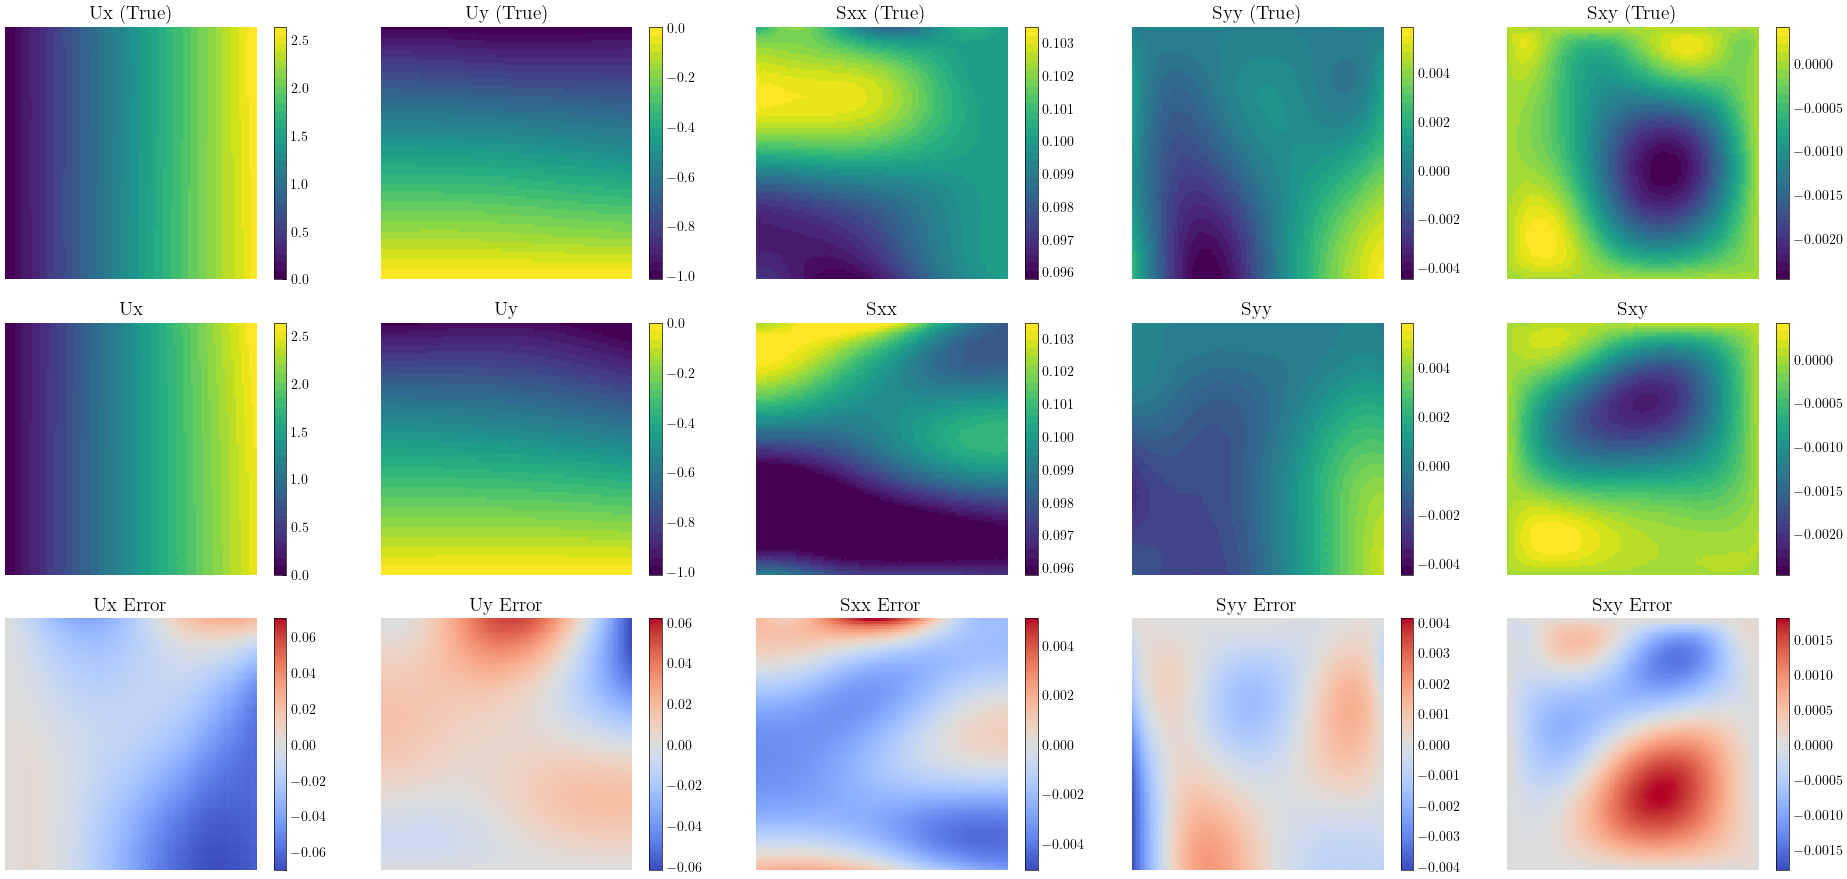

In [46]:
from matplotlib.colors import ListedColormap

cmap = plt.get_cmap('viridis')
num_colors = 30
color_values = [cmap(i) for i in np.linspace(0, 1, num_colors)]
cmap = ListedColormap(color_values)


X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
Y_pred = model.predict([X_input])
Y_pred_fun = lambda x: model.net.apply(model.net.params, x)
Ux_pred = Y_pred[:, 0].reshape(X_mesh.shape).T
Uy_pred = Y_pred[:, 1].reshape(X_mesh.shape).T

S_pred = S_from_output(X_input,(Y_pred,Y_pred_fun),X_input)
Sxx_pred = S_pred[:,0].reshape(X_mesh.shape).T
Syy_pred = S_pred[:,1].reshape(X_mesh.shape).T
Sxy_pred = S_pred[:,2].reshape(X_mesh.shape).T

Ux_true = solution_fn(X_input)[:,0].reshape(X_mesh.shape).T
Uy_true = solution_fn(X_input)[:,1].reshape(X_mesh.shape).T

Sxx_true = stress_fn(X_input)[:,0].reshape(X_mesh.shape).T
Syy_true = stress_fn(X_input)[:,1].reshape(X_mesh.shape).T
Sxy_true = stress_fn(X_input)[:,2].reshape(X_mesh.shape).T

fields = [Ux_pred, Uy_pred, Sxx_pred, Syy_pred, Sxy_pred]
fields_true = [Ux_true, Uy_true, Sxx_true, Syy_true, Sxy_true]
field_names = ["Ux", "Uy", "Sxx", "Syy", "Sxy"]

fig,ax = plt.subplots(3, 5, figsize=(19, 9))

for i in range(5):
    cmax = np.max(fields_true[i])
    cmin = np.min(fields_true[i])
    im = pcolor_plot(ax[0][i], X_mesh, Y_mesh, fields_true[i], field_names[i] + " (True)",colormap=cmap,cmin=cmin,cmax=cmax)
    fig.colorbar(im, ax=ax[0][i])
    
    im = pcolor_plot(ax[1][i], X_mesh, Y_mesh, fields[i], field_names[i],colormap=cmap,cmin=cmin,cmax=cmax)
    fig.colorbar(im, ax=ax[1][i])

    diff = fields[i] - fields_true[i]
    cmax = np.max(np.abs(diff))
    im = pcolor_plot(ax[2][i], X_mesh, Y_mesh, diff, field_names[i] + " Error",colormap="coolwarm",cmin=-cmax,cmax=cmax)
    fig.colorbar(im, ax=ax[2][i])

    for i in range(3):
        ax[i][0].set_aspect("equal", "box")
        ax[i][0].axis("off")

fig.tight_layout()
